# MalApp 技术审计与数据质量复核（2026-08-03）

**TL;DR**：五层评测框架已经具备结构，但当前发布分数不可采信。严格发布集含明显标签代理字段，1,400 条扩展标签仍待双专家复核；服务端管理接口、模型密钥与训练反馈链缺少鉴权隔离；正在运行的旧版 RAG 任务连续失败且未及时熔断。修复顺序应是：评测去泄漏 → 管理面鉴权与密钥隔离 → 工作流预检/熔断 → 训练资产与生产包分离 → 数据库与可观测性治理。

本 Notebook 只执行只读检查，并输出脱敏审计快照与发现表；不会停止后台任务、修改业务数据库或调用外部模型。

## 1. 审计范围与口径

- 代码、桌面发布包、Docker 配置、依赖声明和测试。
- 最新五层套件 `v2-strict1400-20260803_140148-86ca2819`。
- 历史保存输出与正式发布运行严格分开；来源参考标签不等同于专家金标。
- 标签代理字段定义为输入中能直接或近似透露目标标签的业务标签、病毒名或人工结论字段。

In [1]:
from __future__ import annotations

import collections
import csv
import json
import re
import subprocess
from datetime import datetime, timezone
from pathlib import Path

ROOT = Path(r"C:\Users\啤酒肚\Desktop\工作\test1")
SUITE = Path(r"C:\Users\啤酒肚\AppData\Local\MalApp_AgentTrace_LearningLoop\data\evaluation\five_layer\v2-strict1400-20260803_140148-86ca2819")
EVAL_ROOT = SUITE.parents[1]
RELEASE = ROOT / "release" / "MalApp_AgentTrace_LearningLoop_20260803_strict1400_model_coverage_fix"
ANALYSIS_DIR = ROOT / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

def load_jsonl(path: Path):
    with path.open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]

assert ROOT.exists(), ROOT
assert SUITE.exists(), SUITE
print("审计时间（UTC）:", datetime.now(timezone.utc).isoformat())
print("代码目录:", ROOT)
print("评测套件:", SUITE.name)

审计时间（UTC）: 2026-08-03T07:02:30.517868+00:00
代码目录: C:\Users\啤酒肚\Desktop\工作\test1
评测套件: v2-strict1400-20260803_140148-86ca2819


## 2. 严格发布集：数量、标签质量与泄漏检查

In [2]:
manifest = load_json(SUITE / "manifest.json")
baseline = load_json(SUITE / "baseline_scorecards.json")
release_rows = load_jsonl(SUITE / "layer1_model" / "model_release_holdout.jsonl")

label_proxy_fields = {
    "gold_label", "label", "verdict", "malicious", "is_malicious",
    "fraud_category_big", "fraud_category_small", "fraud_category",
    "virus_name", "fraud_flag", "fraud_name", "fraud_type_info",
}
label_counts = collections.Counter()
tier_counts = collections.Counter()
proxy_counts = collections.Counter()
feature_counts = collections.defaultdict(list)
extension_proxy_by_label = collections.Counter()

for row in release_rows:
    label = str((row.get("expected") or {}).get("verdict") or "")
    tier = str(row.get("label_tier") or "")
    sample = row.get("input") or {}
    label_counts[label] += 1
    tier_counts[tier] += 1
    nonempty_features = [
        key for key, value in sample.items()
        if key not in {"md5", "sample_id"} and value not in (None, "", [], {})
    ]
    feature_counts[label].append(len(nonempty_features))
    present_proxies = [
        key for key in sample
        if key.lower() in label_proxy_fields and sample.get(key) not in (None, "", [], {})
    ]
    proxy_counts.update(present_proxies)
    if tier == "source_reference_requires_two_expert_reviews" and present_proxies:
        extension_proxy_by_label[label] += 1

frozen = [r for r in release_rows if r.get("label_tier") == "frozen_validation_gold"]
frozen_labels = collections.Counter((r.get("expected") or {}).get("verdict") for r in frozen)

data_quality = {
    "suite_id": manifest["suite_id"],
    "release_rows": len(release_rows),
    "release_label_counts": dict(label_counts),
    "label_tier_counts": dict(tier_counts),
    "frozen_gold_label_counts": dict(frozen_labels),
    "proxy_field_counts": dict(proxy_counts),
    "extension_rows_with_proxy_by_label": dict(extension_proxy_by_label),
    "feature_count_by_label": {
        label: {
            "min": min(values),
            "median": sorted(values)[len(values) // 2],
            "mean": round(sum(values) / len(values), 3),
            "max": max(values),
        }
        for label, values in feature_counts.items()
    },
    "pending_two_expert_reviews": manifest["selection"]["strict_source_reference_requires_expert_review"],
    "historical_release_outputs": baseline["layer4_e2e"]["release_holdout"]["evaluated_total"],
    "historical_release_coverage": baseline["layer4_e2e"]["release_holdout"]["coverage"],
    "rag_expert_reviews": baseline["layer2_rag"]["evidence_review_count"],
    "agent_trace_coverage": baseline["layer3_agent"]["trace_coverage"],
}

print(json.dumps(data_quality, ensure_ascii=False, indent=2))

{
  "suite_id": "v2-strict1400-20260803_140148-86ca2819",
  "release_rows": 1495,
  "release_label_counts": {
    "malicious": 792,
    "benign": 703
  },
  "label_tier_counts": {
    "source_reference_requires_two_expert_reviews": 1400,
    "frozen_validation_gold": 95
  },
  "frozen_gold_label_counts": {
    "malicious": 92,
    "benign": 3
  },
  "proxy_field_counts": {
    "fraud_category_big": 782,
    "fraud_category_small": 782,
    "virus_name": 95,
    "fraud_flag": 95,
    "fraud_name": 81,
    "fraud_category": 95
  },
  "extension_rows_with_proxy_by_label": {
    "malicious": 700
  },
  "feature_count_by_label": {
    "malicious": {
      "min": 3,
      "median": 3,
      "mean": 6.216,
      "max": 33
    },
    "benign": {
      "min": 0,
      "median": 1,
      "mean": 1.219,
      "max": 27
    }
  },
  "pending_two_expert_reviews": 1400,
  "historical_release_outputs": 86,
  "historical_release_coverage": 0.057525,
  "rag_expert_reviews": 0,
  "agent_trace_coverage":

**解释**：数量已足够支撑第一轮回归，但数据质量尚不满足发布门槛。若恶意样本普遍带“诈骗大类/小类”，而良性样本没有，分类器只需识别字段是否存在即可获得虚高成绩。去掉代理字段后，还必须保证恶意/良性的证据丰富度、来源时间和家族分布可比。

## 3. 代码、接口、发布包与测试审计

In [3]:
source_files = [
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".py", ".js", ".html", ".css"}
    and not any(
        part in {".venv", "release", "build", "dist", "__pycache__"}
        or part.startswith((".build", ".dist"))
        for part in p.parts
    )
]
loc = {}
for path in source_files:
    try:
        loc[str(path.relative_to(ROOT))] = len(path.read_text(encoding="utf-8", errors="replace").splitlines())
    except OSError:
        pass

run_text = (ROOT / "run.py").read_text(encoding="utf-8")
routes = sorted(set(re.findall(r'parsed\.path\s*==\s*"([^"]+)"', run_text)))
rag_auth_calls = run_text.count("rag_request_authorized()")

release_files = [p for p in RELEASE.rglob("*") if p.is_file()]
training_dir = RELEASE / "_internal" / "training_artifacts"
training_files = [p for p in training_dir.rglob("*") if p.is_file()]

repo_profile = {
    "source_files": len(source_files),
    "source_loc": sum(loc.values()),
    "largest_source_files": sorted(loc.items(), key=lambda x: x[1], reverse=True)[:8],
    "unique_api_paths": len(routes),
    "optional_rag_auth_calls": rag_auth_calls,
    "project_ci_present": (ROOT / ".github" / "workflows").exists(),
    "lockfiles_present": [
        name for name in ("uv.lock", "poetry.lock", "Pipfile.lock", "package-lock.json")
        if (ROOT / name).exists()
    ],
    "release_file_count": len(release_files),
    "release_bytes": sum(p.stat().st_size for p in release_files),
    "bundled_training_file_count": len(training_files),
    "bundled_training_bytes": sum(p.stat().st_size for p in training_files),
    "bundled_strict_holdout_assets": [
        str(p.relative_to(RELEASE)) for p in training_files
        if "strict_untrained_release" in p.name
    ],
}
print(json.dumps(repo_profile, ensure_ascii=False, indent=2))

{
  "source_files": 89,
  "source_loc": 37992,
  "largest_source_files": [
    [
      "engine\\debate_flow.py",
      3833
    ],
    [
      "engine\\five_layer_evaluation.py",
      3653
    ],
    [
      "web\\app.js",
      2155
    ],
    [
      "engine\\pipeline.py",
      2005
    ],
    [
      "tools\\create_raw_dialogue_pdf.py",
      1693
    ],
    [
      "ml_pipeline\\pipeline.py",
      1301
    ],
    [
      "tools\\generate_strict_untrained_judgement_set.py",
      1176
    ],
    [
      "engine\\evaluation_framework.py",
      1089
    ]
  ],
  "unique_api_paths": 56,
  "optional_rag_auth_calls": 5,
  "project_ci_present": false,
  "lockfiles_present": [],
  "release_file_count": 954,
  "release_bytes": 3888241047,
  "bundled_training_file_count": 86,
  "bundled_training_bytes": 1129102743,
  "bundled_strict_holdout_assets": [
    "_internal\\training_artifacts\\strict_untrained_release_1000.csv",
    "_internal\\training_artifacts\\strict_untrained_release_1000.

In [4]:
test_cmd = [str(ROOT / ".venv" / "Scripts" / "python.exe"), "-m", "unittest", "discover", "-s", "tests"]
test_run = subprocess.run(test_cmd, cwd=ROOT, text=True, capture_output=True, timeout=120)
test_text = (test_run.stdout or "") + (test_run.stderr or "")
match = re.search(r"Ran\s+(\d+)\s+tests", test_text)
test_profile = {
    "return_code": test_run.returncode,
    "tests_run": int(match.group(1)) if match else None,
    "passed": test_run.returncode == 0,
    "resource_warning_unclosed_database": "unclosed database" in test_text,
    "summary_tail": "\n".join(test_text.strip().splitlines()[-6:]),
}
print(json.dumps(test_profile, ensure_ascii=False, indent=2))

{
  "return_code": 0,
  "tests_run": 50,
  "passed": true,
  "resource_warning_unclosed_database": true,
  "summary_tail": "ResourceWarning: Enable tracemalloc to get the object allocation traceback\n...................................\n----------------------------------------------------------------------\nRan 50 tests in 38.577s\n\nOK"
}


## 4. 当前后台五层任务健康度

In [5]:
job_path = EVAL_ROOT / "five_layer_jobs" / "five-rag_compare-20260803-135906-cd6013.json"
active_job = {}
if job_path.exists():
    job = load_json(job_path)
    run_id = f"{job['job_id']}-rag_off"
    checkpoint_path = EVAL_ROOT / "five_layer_runs" / run_id / "checkpoint.json"
    checkpoint = load_json(checkpoint_path) if checkpoint_path.exists() else {"items": {}}
    statuses = collections.Counter(
        item.get("status") for item in (checkpoint.get("items") or {}).values()
    )
    active_job = {
        "job_id": job.get("job_id"),
        "status": job.get("status"),
        "suite_id": job.get("suite_id"),
        "latest_suite_id": manifest.get("suite_id"),
        "suite_mismatch": job.get("suite_id") != manifest.get("suite_id"),
        "current_command": job.get("current_command"),
        "checkpoint_updated_at": checkpoint.get("updated_at"),
        "checkpoint_status_counts": dict(statuses),
        "last_error_type": "model_endpoint_failure" if statuses.get("failed") else None,
    }
print(json.dumps(active_job, ensure_ascii=False, indent=2))

{
  "job_id": "five-rag_compare-20260803-135906-cd6013",
  "status": "running",
  "suite_id": "v1-20260803_133715-86ca2819",
  "latest_suite_id": "v2-strict1400-20260803_140148-86ca2819",
  "suite_mismatch": true,
  "current_command": "无RAG",
  "checkpoint_updated_at": "2026-08-03T07:03:08.960344+00:00",
  "checkpoint_status_counts": {
    "failed": 48
  },
  "last_error_type": "model_endpoint_failure"
}


## 5. 分级发现与建议

In [6]:
findings = [
    {"priority":"P0","area":"评测有效性","finding":"发布集存在标签代理字段和类别/证据密度偏差","evidence":"782条含诈骗类别字段；1,400扩展中的700条恶意样本全部含代理字段；95冻结金标仅3条良性","action":"从模型输入移除业务结论/病毒结论字段，重建证据等价盲测集；双专家复核后重新冻结"},
    {"priority":"P0","area":"访问控制","finding":"管理与训练反馈接口基本无鉴权","evidence":"56个唯一API路径，仅5处RAG接口调用可选服务密钥；模型设置、人工复核、任务、导出可直接写","action":"默认仅回环监听；统一认证、RBAC、CSRF/Origin校验、审计日志；管理面与推理面分离"},
    {"priority":"P0","area":"密钥/SSRF","finding":"模型设置状态返回明文密钥，且可把带Bearer的探测请求发到任意URL","evidence":"model_runtime_status返回**settings；POST设置后server_model_status请求api_url/models","action":"API永不返回密钥值；凭据进系统密钥库；URL allowlist、阻断内网/重定向、出站代理"},
    {"priority":"P0","area":"任务可靠性","finding":"旧套件RAG任务连续失败仍运行，且与最新套件错配","evidence":"运行进程来自strict400旧版；任务绑定v1，检查时失败样本持续增加","action":"启动前端点冒烟；3次连续同因失败全局熔断；任务固定代码/套件指纹；显式迁移或取消旧任务"},
    {"priority":"P1","area":"训练数据治理","finding":"人工复核和RAG标注可被伪造并进入SFT/DPO","evidence":"reviewer/second_reviewer/status为客户端自由字段；reviewed/adjudicated直接参与导出","action":"服务端身份、角色和双人分离校验；金标不可变版本；导出签名与审批"},
    {"priority":"P1","area":"资源消耗","finding":"请求体、Excel/APK base64与ZIP成员无大小/压缩比限制","evidence":"read_body信任Content-Length；APK整文件和DEX成员一次性读入内存","action":"网关与应用双重限额、流式哈希/解析、ZIP条目数/解压大小/压缩比限制、速率限制"},
    {"priority":"P1","area":"文件系统","finding":"字符串前缀路径校验和任意导出目录","evidence":"serve_static/resolve_user_path使用startswith；datasets/export接受任意resolve路径","action":"Path.relative_to/is_relative_to；导出固定到受控目录并拒绝覆盖"},
    {"priority":"P1","area":"发布治理","finding":"发布包包含训练库、SFT数据和严格集答案","evidence":"发布包约3.89GB；training_artifacts约1.13GB；含strict_untrained_release CSV及gold_label","action":"生产包白名单；评测输入与答案分离；答案仅评测服务持有；生成SBOM和哈希清单"},
    {"priority":"P1","area":"部署","finding":"Docker发布到全部网卡且使用基础http.server；镜像未安装声明依赖","evidence":"compose端口未指定127.0.0.1；Dockerfile无pip install","action":"反向代理TLS/认证或仅回环；生产WSGI；锁定并安装依赖；容器功能一致性测试"},
    {"priority":"P1","area":"数据库","finding":"测试稳定出现未关闭SQLite连接，且未统一WAL/busy_timeout","evidence":"50项测试通过但ResourceWarning: unclosed database；多处with sqlite3.connect","action":"统一connection factory+closing；WAL、busy_timeout、短事务；并发锁与故障注入测试"},
    {"priority":"P1","area":"缓存一致性","finding":"缓存指纹不含提示词、RAG快照、代码、阈值和Agent配置","evidence":"缓存版本仍为2026-06-15，签名主要只有端点与模型名","action":"使用完整inference fingerprint并展示命中来源；评测默认禁用生产缓存"},
    {"priority":"P1","area":"质量门禁","finding":"1,400扩展待双专家复核，RAG专家复核为0，Agent消融/恢复尚未完成","evidence":"manifest与baseline明确标记requires review/ablation","action":"在正式模型比较前先完成金标、RAG relevance gold、五变体与断点恢复"},
    {"priority":"P2","area":"工程质量","finding":"缺少CI、覆盖率门禁、静态类型/安全/依赖审计","evidence":"8个测试文件50项测试；无.github/workflows和锁文件","action":"CI加入unit/integration/security、coverage、ruff/mypy/bandit/pip-audit、构建复现和SBOM"},
    {"priority":"P2","area":"移动恶意分析","finding":"当前APK分析以轻量静态解析为主，缺少行为沙箱和家族/证书谱系","evidence":"静态代码只读Manifest/DEX/证书/SDK；无设备运行状态验证","action":"接入隔离MobSF/Android沙箱、PCAP/API/文件行为、证书与包名谱系、ATT&CK Mobile映射"},
    {"priority":"P2","area":"RAG安全与评测","finding":"缺少检索语料投毒/提示注入/时间衰减专项门禁","evidence":"当前0条专家证据复核；主要报告非空检索率","action":"检索与生成分评；gold doc_id；文档信任等级、时间戳、引用跨度；恶意指令红队集"},
    {"priority":"P2","area":"可观测性/速度","finding":"缺少统一模型/Agent span、token/成本和队列等待分解","evidence":"约90秒/样本，当前只能看总延迟","action":"按预处理/检索/甲乙推理/辩论/落库分段追踪；限流并行、分片断点、吞吐预测"},
]

priority_counts = collections.Counter(item["priority"] for item in findings)
print("发现数量:", dict(sorted(priority_counts.items())))
for item in findings:
    print(f"{item['priority']} | {item['area']} | {item['finding']}")

发现数量: {'P0': 4, 'P1': 8, 'P2': 4}
P0 | 评测有效性 | 发布集存在标签代理字段和类别/证据密度偏差
P0 | 访问控制 | 管理与训练反馈接口基本无鉴权
P0 | 密钥/SSRF | 模型设置状态返回明文密钥，且可把带Bearer的探测请求发到任意URL
P0 | 任务可靠性 | 旧套件RAG任务连续失败仍运行，且与最新套件错配
P1 | 训练数据治理 | 人工复核和RAG标注可被伪造并进入SFT/DPO
P1 | 资源消耗 | 请求体、Excel/APK base64与ZIP成员无大小/压缩比限制
P1 | 文件系统 | 字符串前缀路径校验和任意导出目录
P1 | 发布治理 | 发布包包含训练库、SFT数据和严格集答案
P1 | 部署 | Docker发布到全部网卡且使用基础http.server；镜像未安装声明依赖
P1 | 数据库 | 测试稳定出现未关闭SQLite连接，且未统一WAL/busy_timeout
P1 | 缓存一致性 | 缓存指纹不含提示词、RAG快照、代码、阈值和Agent配置
P1 | 质量门禁 | 1,400扩展待双专家复核，RAG专家复核为0，Agent消融/恢复尚未完成
P2 | 工程质量 | 缺少CI、覆盖率门禁、静态类型/安全/依赖审计
P2 | 移动恶意分析 | 当前APK分析以轻量静态解析为主，缺少行为沙箱和家族/证书谱系
P2 | RAG安全与评测 | 缺少检索语料投毒/提示注入/时间衰减专项门禁
P2 | 可观测性/速度 | 缺少统一模型/Agent span、token/成本和队列等待分解


C:\Temp\ipykernel_29860\447449861.py:12: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_29860\447449861.py:12: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_29860\447449861.py:12: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_29860\447449861.py:12: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_29860\447449861.py:12: UserWarning: Glyph 23457 (\N{CJK UNIFIED IDEOGRAPH-5BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_29860\447449861.py:12: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_29860\447449861.py:12: UserWarning: Glyph 25353 (\N{CJK UN

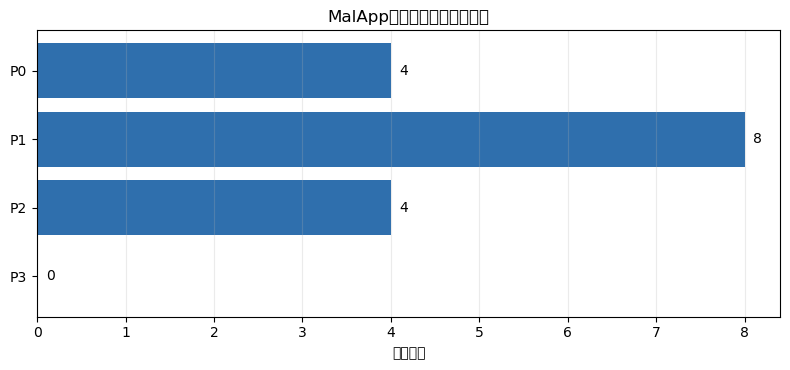

In [7]:
import matplotlib.pyplot as plt

order = ["P0", "P1", "P2", "P3"]
values = [priority_counts.get(p, 0) for p in order]
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(order[::-1], values[::-1], color="#2f6fad")
ax.set_title("MalApp审计发现按优先级分布")
ax.set_xlabel("发现数量")
ax.grid(axis="x", alpha=0.25)
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, str(int(bar.get_width())), va="center")
plt.tight_layout()
plt.show()

## 6. 建议实施顺序

1. **24小时内**：停止把当前发布准确率当有效结论；重建无标签代理输入；重启到最新构建后重新创建与最新套件绑定的任务；模型乙预检失败则不启动批量评测。
2. **3天内**：统一鉴权/RBAC、密钥脱敏和出站URL白名单；限制请求体/APK/ZIP；生产包移除训练与答案资产。
3. **1周内**：完成至少400条双专家金标（良恶平衡、家族/时间/来源分层），并完成100+条RAG相关性金标、五Agent消融和7个可靠性场景。
4. **2周内**：上线CI与依赖锁、SQLite连接工厂/WAL、分段Tracing、分片并行评测、影子/灰度/回退门禁。
5. **后续增强**：引入动态沙箱、ATT&CK Mobile、证书/包名/域名图谱、YARA/行为规则、STIX/TAXII/MISP交换和每周误判回放。

## 7. 输出可复核快照

In [8]:
snapshot = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "data_quality": data_quality,
    "repo_profile": repo_profile,
    "test_profile": test_profile,
    "active_job": active_job,
    "priority_counts": dict(priority_counts),
}
snapshot_path = ANALYSIS_DIR / "malapp_audit_snapshot_20260803.json"
snapshot_path.write_text(json.dumps(snapshot, ensure_ascii=False, indent=2), encoding="utf-8")

findings_path = ANALYSIS_DIR / "malapp_audit_findings_20260803.csv"
with findings_path.open("w", encoding="utf-8-sig", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=["priority", "area", "finding", "evidence", "action"])
    writer.writeheader()
    writer.writerows(findings)

print("快照:", snapshot_path)
print("发现表:", findings_path)

快照: C:\Users\啤酒肚\Desktop\工作\test1\analysis\malapp_audit_snapshot_20260803.json
发现表: C:\Users\啤酒肚\Desktop\工作\test1\analysis\malapp_audit_findings_20260803.csv


## 8. 限制与稳健性说明

- 本审计未对生产端点做攻击性测试，也未停止或修改后台任务。
- 历史输出、来源参考标签和正式双专家金标分别报告；空分母不会伪造为0%或100%。
- 公开案例用于提炼设计模式，不替代你项目自己的回归、红队与人工复核。
- 当前后台任务状态会继续变化；快照记录的是 Notebook 执行时刻。